# 0.5 — Exponents & Logs, at the computer

Do the **pen-and-paper worksheet first**. Here you referee your answers, watch the
multiplication-into-addition trick rescue a real computation, and see why every loss curve
is plotted on a log scale.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 1. Referee the paper work

`**` is power, `np.log2` asks "2 to the what?", `np.log10` asks "10 to the what?",
and plain `np.log` asks "$e$ to the what?" ($\ln$ — ML's default log).

In [2]:
print(2**5, 3**2 * 3**3, 7**0, 2**-3, 9**0.5)     # Part A
print(np.log2(32), np.log10(1000), np.log10(1/100))  # problems 8-9
print(np.log2(80 / 5))                             # problem 11 — your x?

32 243 1 0.125 3.0
5.0 3.0 -2.0
4.0


In [3]:
# YOUR TURN — referee your deep-end work.

# P17: solve eta = eta0 * e^(-k t) for t, with the sympy referee.
#      The pieces you need, assembled — check the output against your paper answer:
eta, eta0, k, t = sp.symbols("eta eta_0 k t", positive=True)
print(sp.solve(sp.Eq(eta, eta0 * sp.exp(-k*t)), t))

# P18: print np.log2(100) and np.log10(100) — was your size-ordering right?
# P19: paper folds to the Moon — compute np.log2(384000e6 / 0.1)
#      (384,000 km in mm) and round UP. Close to your estimate?

[(-log(eta) + log(eta_0))/k]


## 2. THE trick, failing and rescued

A language model scoring a 10,000-word text multiplies 10,000 probabilities. Watch what
happens to the honest product — and how logs save it:

In [4]:
rng = np.random.default_rng(42)               # seeded randomness — same result every run
probs = rng.uniform(0.1, 0.9, size=10_000)    # 10,000 random probabilities

print("the product:      ", np.prod(probs))   # underflows to 0.0 — information destroyed
print("the sum of logs:  ", np.sum(np.log(probs)))   # healthy number, same information

# log(a*b) = log(a) + log(b), ten thousand times over.
# This is why cross-entropy loss is a sum of logs and not a product of probabilities.

the product:       0.0
the sum of logs:   -8355.203968462152


## 3. 🌀 The log-scale X-ray

Here's a realistic training loss: it collapses fast, then grinds. On a normal plot the
interesting part is a smear along the floor. Flip to a log scale and the same data becomes
readable — *and exponential decay straightens into a perfect line*. A straight line on log
axes is the fingerprint of an exponential; you'll use this X-ray on every training run.

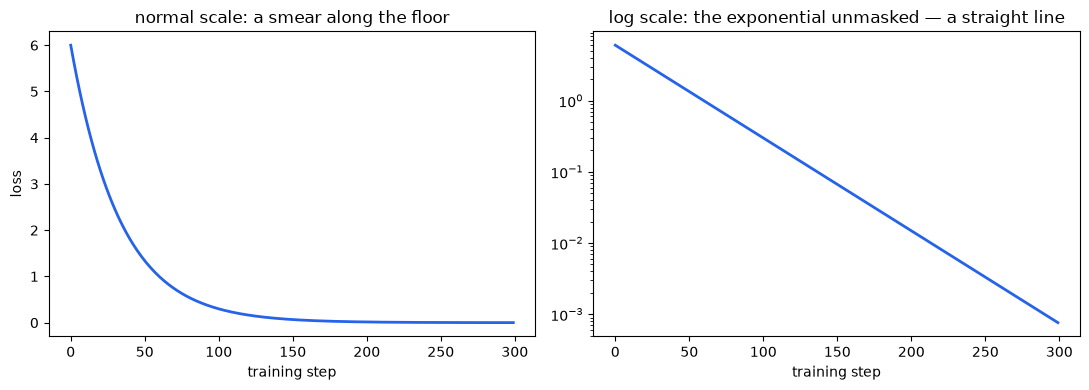

In [5]:
steps = np.arange(0, 300)
loss = 6.0 * np.exp(-0.03 * steps)      # exponential decay: L = 6 e^(-0.03 t)

# one figure, two side-by-side views of the SAME data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(steps, loss, color="#2563eb", linewidth=2)
ax1.set_title("normal scale: a smear along the floor")
ax1.set_xlabel("training step"); ax1.set_ylabel("loss")

ax2.plot(steps, loss, color="#2563eb", linewidth=2)
ax2.set_yscale("log")                    # <- the entire trick
ax2.set_title("log scale: the exponential unmasked — a straight line")
ax2.set_xlabel("training step")
plt.tight_layout()
plt.show()

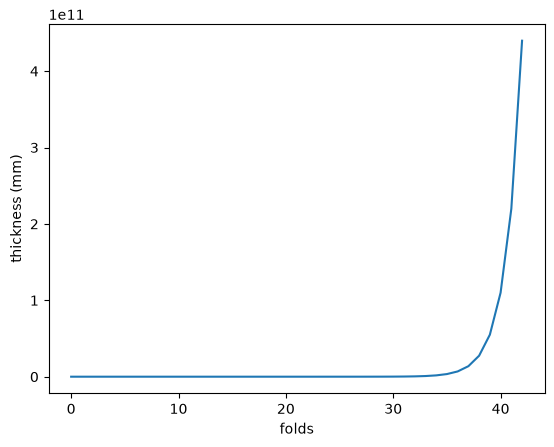

In [6]:
# YOUR TURN — the paper-folding curve (worksheet problem 19).
# thickness after n folds, in mm: 0.1 * 2**n

n = np.arange(0, 43)
thickness = 0.1 * 2.0**n

plt.plot(n, thickness)
# add ONE line here to switch the y-axis to a log scale, then re-run.
# On which version can you actually read the early folds?
plt.xlabel("folds"); plt.ylabel("thickness (mm)")
plt.show()

Your ears (octaves), earthquake scales, decibels, loss curves — nature and engineering
keep reaching for logs because *multiplicative* worlds are everywhere, and logs are the
lens that makes them look additive.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 0.6 — Σ notation, the last piece before the boss.*